In [22]:
%load_ext autoreload
%autoreload 2

In [23]:
import torch
import os
import sys
from GCN import GCN
from GraphSAGE import GraphSAGE
from GAT import GAT

# Import the custom dataset
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from Datasets.garesearch_dataset import GAResearchDataset

from torch_geometric.datasets import HeterophilousGraphDataset
from torch_geometric.loader import DataLoader
import numpy as np
import random
import time
from sklearn.metrics import f1_score, accuracy_score


In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

cuda


In [25]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 0
  }

In [26]:
#dataset = HeterophilousGraphDataset(root ='tmp/Amazon-ratings', name='Amazon-ratings')
#dataset = GAResearchDataset(root ='tmp/amazon-custom', name='amazon')
dataset = GAResearchDataset(root ='tmp/amazon-fasttext-custom', name='amazon-fasttext')

In [27]:
num_features = dataset.num_features
num_classes = dataset.num_classes
num_nodes = dataset[0].num_nodes
num_edges = dataset[0].num_edges

print(f"Number of graphs in dataset: {len(dataset)}")
print(f"Number of features for each node: {num_features}")
print(f"Number of num_classes : {num_classes}")

print(f"Number of num_nodes : {num_nodes}")
print(f"Number of num_edges : {num_edges}")

Number of graphs in dataset: 1
Number of features for each node: 300
Number of num_classes : 5
Number of num_nodes : 24492
Number of num_edges : 186100


In [28]:
# Number of splits available
print(dataset[0].train_mask.shape)
print(dataset[0].test_mask.shape)
print(dataset[0].val_mask.shape)

torch.Size([24492, 10])
torch.Size([24492, 10])
torch.Size([24492, 10])


In [29]:
print(dataset[0].train_mask[:,args['split_idx']])
print(dataset[0].train_mask[:,args['split_idx']].shape)

tensor([ True,  True, False,  ...,  True,  True, False])
torch.Size([24492])


In [30]:
def train(model, data, optimizer, criterion):
    """
    one training epoch
    model -  GNN (GCNConv or GraphSAGE)
    data - Entire Graph Dataset i.e. dataset[0]
    optimizer - algorithm that updates model weights (Adam, SGD, etc.)
    criterion - loss function (often BCEWithLogitsLoss for the PPI dataset)
    """
    #Training mode
    model.train()
    #TODO: Move the data to device outside the training loop
    #data = data.to(device)
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    split_idx = args['split_idx']
    loss = criterion(out[data.train_mask[:,split_idx]], data.y[data.train_mask[:,split_idx]])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [31]:
def test(model, data, mask):
    """
    data: dataset[0] - 1 entire graph composed of all labeled train, test, val
    mask: array of [True, False, ....]
    """
    #switch to evaluation mode
    model.eval()
    # ys: Ground Truth Labels, preds: model predictions across all batches
    ys, preds = [], []

    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out[mask].argmax(dim=1).cpu().numpy()
    y = data.y[mask].cpu().numpy()
    
    #macro - how model handles small classes
    f1 = f1_score(y, pred, average='macro', zero_division=0)
    acc = accuracy_score(y, pred)
    return f1, acc
        

In [32]:
def train_and_evaluate(model, data, optimizer, scheduler, criterion, epochs=100):
    best_val_f1 = 0
    train_losses, val_f1s, val_accs, test_f1s, test_accs = [],[],[],[],[]
    training_time = 0

    for epoch in range(1, epochs+1):
        start_time = time.time()

        loss = train(model, data, optimizer, criterion)
        
        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        training_time += epoch_time

        split_idx = args['split_idx']
        val_f1, val_acc = test(model, data, data.val_mask[:,split_idx])
        test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])

        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model_gcn.pth')

        if epoch % 1 == 0:
            print(f"Epoch: {epoch:03d}, "
                f"Loss: {loss:.4f}, "
                f"Val F1: {val_f1:.4f},"
                f"Val Acc: {val_acc:.4f}, "
                f"Time: {epoch_time:.2f}s"
                )


    model.load_state_dict(torch.load('best_model_gcn.pth', map_location=device))
    test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    return model, train_losses, val_f1s, test_f1s, training_time

In [33]:
def build_optimizer(args, params):
    
    filter_fn = filter(lambda p : p.requires_grad, params)
    weight_decay = args['weight_decay']
    if args['opt'] == 'adam':
        optimizer = torch.optim.Adam(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'sgd':
        optimizer = torch.optim.SGD(filter_fn, lr=args['lr'], momentum=0.95, weight_decay=weight_decay)
    elif args['opt'] == 'rmsprop':
        optimizer = torch.optim.RMSprop(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'adagrad':
        optimizer = torch.optim.Adagrad(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    if args['opt_scheduler'] == 'none':
        return None, optimizer
    elif args['opt_scheduler'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args['opt_decay_step'], gamma=args['opt_decay_rate'])
    elif args['opt_scheduler'] == 'cos':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args['opt_restart'])
    return scheduler, optimizer

In [34]:
import matplotlib.pyplot as plt
def plot_results(results, title, label, ylabel):
    plt.figure(figsize=(3,2))
    epochs = range(1, len(results)+1)
    plt.plot(epochs, results, label = label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

In [35]:
def gcn_run():
    model = GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


Training GCN
Epoch: 001, Loss: 1.9436, Val F1: 0.1638,Val Acc: 0.6931, Time: 3.64s
Epoch: 002, Loss: 1.7176, Val F1: 0.1947,Val Acc: 0.5098, Time: 0.01s
Epoch: 003, Loss: 1.5968, Val F1: 0.0832,Val Acc: 0.2626, Time: 0.01s
Epoch: 004, Loss: 1.0251, Val F1: 0.0852,Val Acc: 0.2501, Time: 0.01s
Epoch: 005, Loss: 0.9538, Val F1: 0.0872,Val Acc: 0.2307, Time: 0.01s
Epoch: 006, Loss: 0.8773, Val F1: 0.0893,Val Acc: 0.2505, Time: 0.01s
Epoch: 007, Loss: 0.8155, Val F1: 0.1904,Val Acc: 0.4657, Time: 0.01s
Epoch: 008, Loss: 0.7805, Val F1: 0.1992,Val Acc: 0.6931, Time: 0.01s
Epoch: 009, Loss: 0.7694, Val F1: 0.1638,Val Acc: 0.6931, Time: 0.01s
Epoch: 010, Loss: 0.7776, Val F1: 0.1638,Val Acc: 0.6931, Time: 0.01s
Epoch: 011, Loss: 0.7514, Val F1: 0.1638,Val Acc: 0.6931, Time: 0.01s
Epoch: 012, Loss: 0.7158, Val F1: 0.1638,Val Acc: 0.6931, Time: 0.01s
Epoch: 013, Loss: 0.7036, Val F1: 0.1638,Val Acc: 0.6931, Time: 0.01s
Epoch: 014, Loss: 0.7037, Val F1: 0.1638,Val Acc: 0.6931, Time: 0.01s
Epoch: 

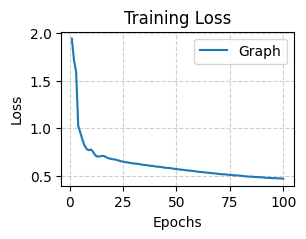

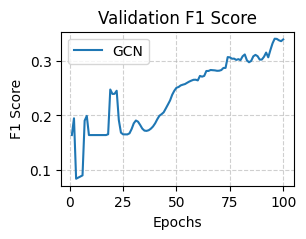

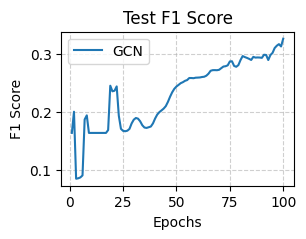

In [36]:
gcn_run()

In [37]:
def graphSage_run():
    model = GraphSAGE(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training Graph SAGE")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data,
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GraphSAGE','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GraphSAGE','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GraphSAGE','F1 Score')


Training Graph SAGE
Epoch: 001, Loss: 1.8388, Val F1: 0.1638,Val Acc: 0.6931, Time: 0.34s
Epoch: 002, Loss: 1.5732, Val F1: 0.1685,Val Acc: 0.4733, Time: 0.01s
Epoch: 003, Loss: 2.5554, Val F1: 0.1763,Val Acc: 0.6905, Time: 0.01s
Epoch: 004, Loss: 1.5945, Val F1: 0.1638,Val Acc: 0.6931, Time: 0.01s
Epoch: 005, Loss: 1.4716, Val F1: 0.1638,Val Acc: 0.6931, Time: 0.01s
Epoch: 006, Loss: 1.2788, Val F1: 0.1638,Val Acc: 0.6931, Time: 0.01s
Epoch: 007, Loss: 1.0815, Val F1: 0.1714,Val Acc: 0.6858, Time: 0.01s
Epoch: 008, Loss: 1.0102, Val F1: 0.1699,Val Acc: 0.6913, Time: 0.01s
Epoch: 009, Loss: 0.9460, Val F1: 0.1675,Val Acc: 0.6923, Time: 0.01s
Epoch: 010, Loss: 0.9341, Val F1: 0.1966,Val Acc: 0.5574, Time: 0.01s
Epoch: 011, Loss: 0.9165, Val F1: 0.1512,Val Acc: 0.3695, Time: 0.01s
Epoch: 012, Loss: 0.8413, Val F1: 0.1304,Val Acc: 0.3230, Time: 0.01s
Epoch: 013, Loss: 0.7993, Val F1: 0.1759,Val Acc: 0.4492, Time: 0.01s
Epoch: 014, Loss: 0.7947, Val F1: 0.1865,Val Acc: 0.6019, Time: 0.01s


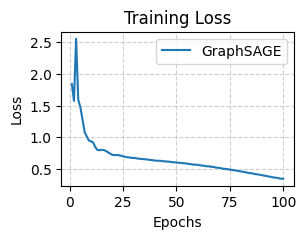

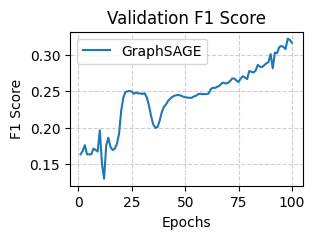

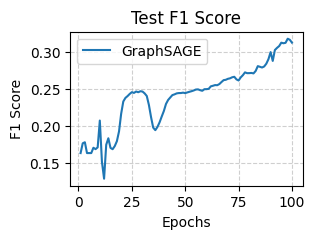

In [38]:
graphSage_run()

In [17]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


Training GAT
Epoch: 001, Loss: 1.9747, Val F1: 0.1628,Val Acc: 0.6840, Time: 1.32s
Epoch: 002, Loss: 2.5716, Val F1: 0.0853,Val Acc: 0.2709, Time: 0.04s
Epoch: 003, Loss: 2.4007, Val F1: 0.1636,Val Acc: 0.6833, Time: 0.03s
Epoch: 004, Loss: 1.7397, Val F1: 0.1625,Val Acc: 0.6840, Time: 0.03s
Epoch: 005, Loss: 1.1495, Val F1: 0.1625,Val Acc: 0.6840, Time: 0.03s
Epoch: 006, Loss: 0.9939, Val F1: 0.1625,Val Acc: 0.6840, Time: 0.03s
Epoch: 007, Loss: 0.9660, Val F1: 0.1624,Val Acc: 0.6837, Time: 0.03s
Epoch: 008, Loss: 0.9215, Val F1: 0.1673,Val Acc: 0.6821, Time: 0.03s
Epoch: 009, Loss: 0.8870, Val F1: 0.1726,Val Acc: 0.6766, Time: 0.03s
Epoch: 010, Loss: 0.8769, Val F1: 0.1788,Val Acc: 0.6595, Time: 0.03s
Epoch: 011, Loss: 0.9141, Val F1: 0.1878,Val Acc: 0.6343, Time: 0.03s
Epoch: 012, Loss: 0.9115, Val F1: 0.2164,Val Acc: 0.6313, Time: 0.03s
Epoch: 013, Loss: 0.8862, Val F1: 0.2265,Val Acc: 0.6066, Time: 0.03s
Epoch: 014, Loss: 0.8584, Val F1: 0.2356,Val Acc: 0.5962, Time: 0.03s
Epoch: 

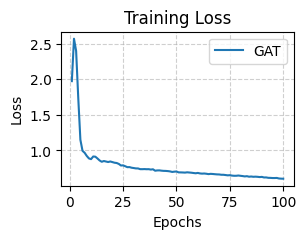

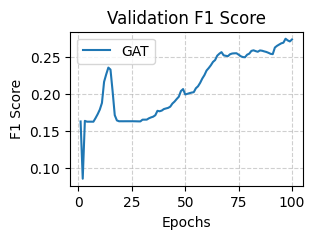

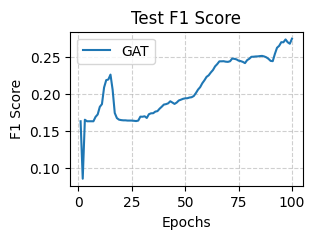

In [18]:
gat_run()